# Heston Model Calibration on Real Market Data 

This notebook calibrates the Heston stochastic volatility model to option quotes for a **single quote date**. It supports both calls and puts, computes model prices, converts model and market prices into Black implied volatilities, evaluates in-sample and holdout errors, and visualizes implied-volatility smiles and surfaces.


### Heston Stochastic Volatility Model

The Heston model assumes that the underlying asset price follows:

$$
dS_t = rS_t dt + \sqrt{v_t}S_t dW_t^S
$$

The variance process follows:

$$
dv_t = \kappa(\theta - v_t) dt + \sigma\sqrt{v_t} dW_t^v
$$

The two Brownian motions are correlated:

$$
dW_t^S dW_t^v = \rho dt
$$

The model parameters are:    
$v_0$ - Initial variance  
$\kappa$ - Speed of mean reversion  
$\theta$ - Long-run variance  
$\sigma$ - Volatility of variance  
$\rho$ - Correlation between asset and variance shocks  
$\lambda$ - Volatility risk premium. In this implementation, the volatility risk premium is fixed at: $\lambda = 0$

The calibrated parameter vector is therefore:  
$$
\Theta = (v_0, \kappa, \theta, \sigma, \rho)
$$

### Heston Characteristic Function  
The code evaluates the Heston characteristic function in vectorized form over all integration nodes and all option contracts.

The following quantities are used:

$$ a = \kappa\theta $$

$$ b = \kappa + \lambda $$

$$ d = \sqrt{(\rho\sigma i\phi - b)^2 + \sigma^2(i\phi + \phi^2)} $$

$$ g = \frac{b - \rho\sigma i\phi + d}{b - \rho\sigma i\phi - d}$$

The characteristic function is then evaluated for the transformed integration variable $\phi$ and maturity $\tau$.


### Heston Call Pricing Formula

The Heston call price is computed using Fourier inversion and numerical integration.

The call price is:

$$
C =
\frac{S_0 - Ke^{-rT}}{2}
+
\frac{1}{\pi}
\int_0^\infty
\Re
\left[
\frac{
e^{rT}\varphi(\phi - i) - K\varphi(\phi)
}{
i\phi K^{i\phi}
}
\right]
d\phi
$$

where:  
* $S_0$ is the spot or spot proxy,
* $K$ is the strike,
* $T$ is time to maturity,
* $r$ is the risk-free rate,
* $\varphi(\cdot)$ is the Heston characteristic function,
* $\Re[\cdot]$ denotes the real part.

The integral is approximated using Gauss-Legendre quadrature over the finite interval:

$$ [0, U_{\max}] $$

The number of integration nodes is controlled by N_INT.

### Put Pricing Using Put-Call Parity

The implemented Heston formula directly computes call prices. Put prices are obtained from forward put-call parity.

The parity relationship is:

$$ C - P = e^{-rT}(F - K) $$

Solving for the put price gives:

$$ P = C - e^{-rT}(F - K) $$

### Calibration Objective

The optimizer solves a bounded nonlinear least-squares problem.

The objective is:

$$
\min_{\Theta}
\sum_{i=1}^{N}
\left(
\epsilon_i^2
\right)
$$

The residual is:

$$
\epsilon_i =
\frac{
V_i^{\text{Heston}}(\Theta) - V_i^{\text{market}}
}{
\text{spread}_i
}
$$

#### Import packages

In [1]:
# ============================================================
# 0. Imports
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path
from scipy.optimize import least_squares, brentq
from scipy.stats import norm
from scipy.interpolate import griddata
from numpy.polynomial.legendre import leggauss

import matplotlib.pyplot as plt
import plotly.graph_objects as go

from nelson_siegel_svensson.calibrate import calibrate_nss_ols

#### Configuration of params

In [2]:
# ============================================================
# 1. Configuration
# ============================================================

DATA_PATH = Path('/Users/uran/Desktop/ErdosBootcamp/Project_Quant_Finance/Quant-Finance-project/Processed_data/surface_all.parquet')

TICKER = "SPX"
QUOTE_DATE = "2023-01-04"

HOLDOUT_FRAC = 0.2
MIN_VISIBLE = 6
SPLIT_SEED = 0

# Heston integration settings
UMAX = 200.0
N_INT = 64        # 64 already matches a reference pricer to ~1e-6; raise to 128 for a final run

# Implied-volatility inversion bounds
IV_LOW = 1e-6
IV_HIGH = 5.0

#### Prepare data

In [3]:
# ============================================================
# 2. Load data
# ============================================================

df = pd.read_parquet(DATA_PATH)
df = df[df["ticker"] == TICKER].copy().reset_index(drop=True)
df["type"] = df["type"].astype(str).str.lower()
print(f"{TICKER}: {len(df):,} quotes over {df['quote_date'].nunique()} quote dates")

SPX: 1,462,299 quotes over 249 quote dates


In [4]:
# ============================================================
# 3. Train / holdout split
# ============================================================

def make_holdout(frame, frac=0.2, min_vis=6, seed=0):
    """
    Randomly select holdout quotes inside each
    ticker / quote_date / expire_date group, while keeping at least
    min_vis visible quotes per group.
    """
    rng = np.random.default_rng(seed)
    hold = pd.Series(False, index=frame.index)

    for _, sl in frame.groupby(["ticker", "quote_date", "expire_date"]):
        n = len(sl)
        n_hold = min(int(round(frac * n)), max(0, n - min_vis))

        if n_hold > 0:
            idx = rng.choice(sl.index.values, size=n_hold, replace=False)
            hold.loc[idx] = True

    return hold


df["is_holdout"] = make_holdout(
    df,
    frac=HOLDOUT_FRAC,
    min_vis=MIN_VISIBLE,
    seed=SPLIT_SEED,
)

# Day-level feature using visible data only
lvl = (
    df.loc[~df["is_holdout"]]
      .groupby(["ticker", "quote_date"])["iv"]
      .median()
      .rename("day_level")
      .reset_index()
)

df = df.merge(lvl, on=["ticker", "quote_date"], how="left")
df["day_level"] = df["day_level"].fillna(df["iv"].median())

n_vis = int((~df["is_holdout"]).sum())
n_hold = int(df["is_holdout"].sum())

print(f"Visible: {n_vis:,}")
print(f"Holdout: {n_hold:,}")

Visible: 1,169,769
Holdout: 292,530


In [5]:
# ============================================================
# 4. Filter to one quote date
# ============================================================

train = df.loc[~df["is_holdout"]].copy()
test = df.loc[df["is_holdout"]].copy()

train = train[train["quote_date"] == QUOTE_DATE].copy()
test = test[test["quote_date"] == QUOTE_DATE].copy()

print(f"Training set before calibration filters: {len(train):,}")
print(f"Test set before calibration filters: {len(test):,}")

Training set before calibration filters: 4,408
Test set before calibration filters: 1,103


In [6]:
train.head()

,ticker,quote_date,expire_date,dte,tau,underlying_last,forward,strike,log_moneyness,type,bid,ask,mid,iv,total_var,delta,volume,is_holdout,day_level
0,SPX,2023-01-04,2023-01-11,7.0,0.019178,3853.39,3853.39,3100.0,-0.217551,put,0.05,0.15,0.100,0.50099,0.004814,-0.00119,4.0,False,0.219185
2,SPX,2023-01-04,2023-01-11,7.0,0.019178,3853.39,3853.39,3200.0,-0.185802,put,0.05,0.20,0.125,0.44229,0.003752,-0.00167,1320.0,False,0.219185
3,SPX,2023-01-04,2023-01-11,7.0,0.019178,3853.39,3853.39,3250.0,-0.170298,put,0.10,0.15,0.125,0.40815,0.003195,-0.00220,50.0,False,0.219185
5,SPX,2023-01-04,2023-01-11,7.0,0.019178,3853.39,3853.39,3350.0,-0.139993,put,0.15,0.25,0.200,0.35729,0.002448,-0.00309,665.0,False,0.219185
6,SPX,2023-01-04,2023-01-11,7.0,0.019178,3853.39,3853.39,3400.0,-0.125178,put,0.15,0.25,0.200,0.32338,0.002006,-0.00310,1900.0,False,0.219185


In [7]:
test.head()

,ticker,quote_date,expire_date,dte,tau,underlying_last,forward,strike,log_moneyness,type,bid,ask,mid,iv,total_var,delta,volume,is_holdout,day_level
1,SPX,2023-01-04,2023-01-11,7.0,0.019178,3853.39,3853.39,3150.0,-0.201551,put,0.05,0.1,0.075,0.45581,0.003984,-0.00111,60.0,True,0.219185
4,SPX,2023-01-04,2023-01-11,7.0,0.019178,3853.39,3853.39,3300.0,-0.155031,put,0.10,0.2,0.150,0.38134,0.002789,-0.00238,565.0,True,0.219185
7,SPX,2023-01-04,2023-01-11,7.0,0.019178,3853.39,3853.39,3450.0,-0.110579,put,0.20,0.3,0.250,0.29607,0.001681,-0.00458,179.0,True,0.219185
17,SPX,2023-01-04,2023-01-11,7.0,0.019178,3853.39,3853.39,3610.0,-0.065246,put,0.55,0.7,0.625,0.20920,0.000839,-0.01462,57.0,True,0.219185
26,SPX,2023-01-04,2023-01-11,7.0,0.019178,3853.39,3853.39,3660.0,-0.051490,put,1.35,1.5,1.425,0.19509,0.000730,-0.03307,37.0,True,0.219185


## Risk-free curve

This example uses a Nelson-Siegel-Svensson fit to a Treasury par-yield vector. For production pricing, a zero-rate or discount-factor curve is preferable.

For 2023-01-04 go to https://home.treasury.gov/resource-center/data-chart-center/interest-rates/daily-treasury-rate-archives/par-yield-curve-rates-2020-2023.xml

In [8]:
# ============================================================
# 5. Risk-free rate curve
# ============================================================

yield_maturities = np.array([1/12, 2/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30], dtype=float)

treasury_yields = np.array([4.20, 4.42, 4.55, 4.77, 4.71, 4.36, 4.11, 3.85, 3.79, 3.69, 3.97, 3.81], dtype=float) / 100.0

curve_fit, status = calibrate_nss_ols(yield_maturities, treasury_yields)

train["rate"] = train["tau"].apply(curve_fit).astype(float)
test["rate"] = test["tau"].apply(curve_fit).astype(float)

### Heston model: characteristic function, etc.

In [9]:
# ============================================================
# 6. Fast vectorized Heston pricing (forward measure)
# ============================================================

x_gl, w_gl = leggauss(N_INT)

# Transform Gauss-Legendre nodes from [-1, 1] to [0, UMAX]
PHI = 0.5 * UMAX * (x_gl + 1.0)
W = 0.5 * UMAX * w_gl


def heston_charfunc_vec(phi, S0, v0, kappa, theta, sigma, rho, lambd, tau, r):
    """
    Vectorized Heston characteristic function of log-price.

    phi shape: (n_phi, 1)
    S0, tau, r broadcast against phi.
    For forward-measure pricing we pass S0 = forward F and r = 0, which gives
    the characteristic function of ln(F_T) where F_T is a martingale with F_0 = F.
    """
    i = 1j

    a = kappa * theta
    b = kappa + lambd

    rspi = rho * sigma * phi * i

    d = np.sqrt((rho * sigma * phi * i - b) ** 2 + sigma ** 2 * (phi * i + phi ** 2))

    g = (b - rspi + d) / (b - rspi - d)

    exp1 = np.exp(r * phi * i * tau)

    term2 = (S0 ** (phi * i) * ((1 - g * np.exp(d * tau)) / (1 - g)) ** (-2 * a / sigma ** 2))

    exp2 = np.exp(a * tau * (b - rspi + d) / sigma ** 2 + v0 * (b - rspi + d) * ((1 - np.exp(d * tau)) / (1 - g * np.exp(d * tau))) / sigma ** 2)

    return exp1 * term2 * exp2


def heston_call_fwd(F, K, v0, kappa, theta, sigma, rho, lambd, tau, r):
    """
    Vectorized European call under Heston, priced in the forward measure.

    F, K, tau, r are 1D arrays of equal length (one entry per option).
    Returns the discounted call price array.

    C = exp(-r*tau) * (F*P1 - K*P2), with
        P2 = 1/2 + 1/pi * Int Re[ K^{-i*phi} * f(phi)     / (i*phi) ] dphi
        P1 = 1/2 + 1/pi * Int Re[ K^{-i*phi} * f(phi - i) / (i*phi) ] dphi / F
    where f is the characteristic function of ln(F_T) (martingale, f(-i) = F).
    """
    F = np.asarray(F, dtype=float)
    K = np.asarray(K, dtype=float)
    tau = np.asarray(tau, dtype=float)
    r = np.asarray(r, dtype=float)

    phi = PHI[:, None]
    weights = W[:, None]

    Fb = F[None, :]
    Kb = K[None, :]
    tb = tau[None, :]

    # CF of ln(F_T): pass "spot" = F and r = 0 (forward measure).
    f0 = heston_charfunc_vec(phi, Fb, v0, kappa, theta, sigma, rho, lambd, tb, 0.0)
    f1 = heston_charfunc_vec(phi - 1j, Fb, v0, kappa, theta, sigma, rho, lambd, tb, 0.0)

    Kfac = Kb ** (-1j * phi)

    P2 = 0.5 + np.sum(weights * np.real(Kfac * f0 / (1j * phi)), axis=0) / np.pi
    # f(-i) = F exactly, so divide by F instead of evaluating the CF at phi = -i (a 0/0 point)
    P1 = 0.5 + np.sum(weights * np.real(Kfac * f1 / (1j * phi)), axis=0) / (np.pi * F)

    return np.exp(-r * tau) * (F * P1 - K * P2)


def heston_price_by_type(F, K, option_type, v0, kappa, theta, sigma, rho, lambd, tau, r):
    """
    Heston model prices for calls and puts.

    Calls are priced directly; puts come from forward put-call parity:
        put = call - exp(-r*tau) * (F - K)
    """
    call_price = heston_call_fwd(F, K, v0, kappa, theta, sigma, rho, lambd, tau, r)

    F = np.asarray(F, dtype=float)
    K = np.asarray(K, dtype=float)
    tau = np.asarray(tau, dtype=float)
    r = np.asarray(r, dtype=float)
    option_type = np.char.lower(np.asarray(option_type).astype(str))

    put_price = call_price - np.exp(-r * tau) * (F - K)

    return np.where(option_type == "put", put_price, call_price)

In [10]:
# ============================================================
# 7. Black-Scholes price and implied volatility (with no-arbitrage guards)
# ============================================================

def bs_price(F, K, T, r, sigma, option_type):
    """
    Black-Scholes price for European options on forwards.
        F: forward price
        K: strike price
        T: time to maturity (in years)
        r: risk-free rate
        sigma: volatility
        option_type: "call" or "put"
    Returns NaN if any input is non-positive or option_type is invalid, 
            otherwise returns the discounted Black-Scholes price.
    """
    if T <= 0 or sigma <= 0 or F <= 0 or K <= 0:
        return np.nan

    d1 = (np.log(F / K) + 0.5 * sigma ** 2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return F * norm.cdf(d1) * np.exp(-r * T) - K * norm.cdf(d2) * np.exp(-r * T)
    elif option_type == "put":
        return K * norm.cdf(-d2) * np.exp(-r * T) - F * norm.cdf(-d1) * np.exp(-r * T)


def implied_vol_bs(price, F, K, T, r, option_type, low=IV_LOW, high=IV_HIGH):
    """
    Black-Scholes implied volatility for calls or puts.
        price: option price
        F: forward price
        K: strike price
        T: time to maturity (in years)
        r: risk-free rate
        option_type: "call" or "put"
        low: lower bound for root finding (default: IV_LOW)
        high: upper bound for root finding (default: IV_HIGH)
    Calculates the implied volatility by finding the root of the equation:
        bs_price(F, K, T, r, sigma, option_type) - price = 0
    using Brent's method.
    """
    if not all(np.isfinite(v) for v in [price, F, K, T, r]) or price <= 0 or F <= 0 or K <= 0 or T <= 0:
        return np.nan

    def objective(sig):
        return bs_price(F, K, T, r, sig, option_type) - price
   
    return brentq(objective, low, high, maxiter=100, xtol=1e-8)

## Calibration objective

In [11]:
# ============================================================
# 8. Build calibration set
# ============================================================

train_calib = train.copy()
train_calib = train_calib[train_calib["mid"] > 1] # filter out very low-priced options to avoid numerical issues in calibration
train_calib["moneyness"] = train_calib["strike"] / train_calib["forward"]

# ============================================================
# 9. Calibration arrays
# ============================================================

K = train_calib["strike"].to_numpy(float)
tau = train_calib["tau"].to_numpy(float)
r = train_calib["rate"].to_numpy(float)
F = train_calib["forward"].to_numpy(float)
P = train_calib["mid"].to_numpy(float)
option_type = train_calib["type"].to_numpy(str)
IV = train_calib["iv"].to_numpy(float)

train_calib["spread"] = (train_calib["ask"] - train_calib["bid"]).clip(lower=0.05)
spread = train_calib["spread"].to_numpy(float)

print(f"Final calibration vector length: {len(P):,}")
print(pd.Series(option_type).value_counts())

# ============================================================
# 10. Calibration objective
# ============================================================

params = {
    "v0":    {"x0": 0.04, "lbub": [1e-4, 0.5]},
    "kappa": {"x0": 2.0,  "lbub": [1e-3, 10.0]},
    "theta": {"x0": 0.04, "lbub": [1e-4, 0.5]},
    "sigma": {"x0": 0.5,  "lbub": [1e-2, 3.0]},
    "rho":   {"x0": -0.7, "lbub": [-0.999, 0.999]},
}

param_names = list(params.keys())

x0 = np.array([v["x0"] for v in params.values()], dtype=float)
lower = np.array([v["lbub"][0] for v in params.values()], dtype=float)
upper = np.array([v["lbub"][1] for v in params.values()], dtype=float)
bounds = (lower, upper)

def residuals_heston(x):
    v0, kappa, theta, sigma, rho = x
    lambd = 0.0

    model_price = heston_price_by_type(F=F, K=K, option_type=option_type, v0=v0, kappa=kappa, theta=theta, sigma=sigma, rho=rho, lambd=lambd, tau=tau, r=r)
    
    # Spread-weighted price residuals: errors measured in bid-ask-spread units.
    resid = (model_price - P) / spread

    # # Soft Feller penalty: 2*kappa*theta >= sigma^2
    # feller_violation = max(0.0, sigma ** 2 - 2.0 * kappa * theta)
    # resid = np.concatenate([resid, np.array([10.0 * feller_violation])])

    # model_iv = np.array([
    #     implied_vol_bs(mp, f, k, t, rr, typ)
    #     for mp, f, k, t, rr, typ in zip(model_price, F, K, tau, r, option_type)
    # ])
    # resid = model_iv - IV
    # resid[~np.isfinite(resid)] = 10.0

    return resid

Final calibration vector length: 3,939
put     2320
call    1619
Name: count, dtype: int64


In [12]:
# ============================================================
# 11. Run calibration
# ============================================================

result = least_squares(residuals_heston, 
                       x0, bounds=bounds, method="trf",
                       loss="huber",     # other options: "linear", "huber"
                       f_scale=0.1, max_nfev=200, verbose=2)

calibrated_params = dict(zip(param_names, result.x))

print("\nCalibration result")
print("------------------")
print("Success:", result.success)
print("Message:", result.message)
print("Cost:", result.cost)

for name, value in calibrated_params.items():
    print(f"{name:>6s}: {value:.8f}")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.6212e+03                                    1.80e+05    


/var/folders/v5/cysx2bbs2s14yg6zy94dwf2m0000gq/T/ipykernel_52636/1943938246.py:36: RuntimeWarning: overflow encountered in exp
  exp2 = np.exp(a * tau * (b - rspi + d) / sigma ** 2 + v0 * (b - rspi + d) * ((1 - np.exp(d * tau)) / (1 - g * np.exp(d * tau))) / sigma ** 2)
/var/folders/v5/cysx2bbs2s14yg6zy94dwf2m0000gq/T/ipykernel_52636/1943938246.py:38: RuntimeWarning: invalid value encountered in multiply
  return exp1 * term2 * exp2


       1              5         3.8979e+03      1.72e+03       1.21e-02       1.49e+04    
       2              6         3.2922e+03      6.06e+02       8.88e-03       1.36e+04    
       3              7         2.4990e+03      7.93e+02       2.67e-02       9.37e+03    
       4              8         2.3618e+03      1.37e+02       3.24e-02       1.20e+04    
       5              9         2.3388e+03      2.30e+01       1.52e-01       1.44e+03    
       6             10         2.3260e+03      1.28e+01       2.05e-01       4.06e+03    
       7             11         2.3239e+03      2.11e+00       5.61e-01       7.40e+03    
       8             12         2.3214e+03      2.49e+00       1.64e-01       6.44e+01    
       9             13         2.3211e+03      3.21e-01       1.28e-01       4.33e+02    
      10             14         2.3210e+03      2.13e-02       5.89e-03       4.82e+00    
      11             15         2.3210e+03      5.22e-04       4.99e-03       5.79e-01    

In [13]:
# ============================================================
# 13. In-sample prices and implied volatilities
# ============================================================

v0, kappa, theta, sigma, rho = result.x
lambd = 0.0

model_prices = heston_price_by_type(F=F, K=K, option_type=option_type, v0=v0, kappa=kappa, theta=theta, sigma=sigma, rho=rho, lambd=lambd, tau=tau, r=r,)

train_result = pd.DataFrame({
    "type": option_type,
    "strike": K,
    "tau": tau,
    "rate": r,
    "forward": F,
    "moneyness": K / F,
    "mid": P,
    "iv": IV,
    "heston_price": model_prices,
})

train_result["market_iv_from_mid"] = train_result["iv"]

for i, row in train_result.iterrows():
    heston_price = row["heston_price"]
    fwd = row["forward"]
    strike = row["strike"]
    t = row["tau"]
    rate = row["rate"]
    opt_type = row["type"]
    train_result.at[i, "heston_iv"] = implied_vol_bs(heston_price, fwd, strike, t, rate, opt_type)

# Calculate price and implied volatility errors
train_result["price_error"] = train_result["heston_price"] - train_result["mid"]
train_result["rel_price_error"] = train_result["price_error"] / np.maximum(train_result["mid"], 1e-8)
train_result["iv_error"] = train_result["heston_iv"] - train_result["market_iv_from_mid"]

In [14]:
# ============================================================
# 14. In-sample RMSE diagnostics. Train data
# ============================================================

valid_price = np.isfinite(train_result["mid"]) & np.isfinite(train_result["heston_price"])
valid_iv = np.isfinite(train_result["market_iv_from_mid"]) & np.isfinite(train_result["heston_iv"])

price_rmse = np.sqrt(np.mean(train_result.loc[valid_price, "price_error"] ** 2))
price_mae = np.mean(np.abs(train_result.loc[valid_price, "price_error"]))
price_mape = np.mean(np.abs(train_result.loc[valid_price, "rel_price_error"]))

iv_rmse = np.sqrt(np.mean(train_result.loc[valid_iv, "iv_error"] ** 2))
iv_mae = np.mean(np.abs(train_result.loc[valid_iv, "iv_error"]))

print("In-sample price diagnostics")
print("---------------------------")
print(f"Price RMSE: {price_rmse:.6f}")
print(f"Price MAE:  {price_mae:.6f}")
print(f"Price MAPE: {price_mape:.4%}")
print()
print("In-sample implied-volatility diagnostics")
print("----------------------------------------")
print(f"IV RMSE: {iv_rmse:.6f}")
print(f"IV MAE:  {iv_mae:.6f}")

In-sample price diagnostics
---------------------------
Price RMSE: 9.775114
Price MAE:  5.056057
Price MAPE: 12.9397%

In-sample implied-volatility diagnostics
----------------------------------------
IV RMSE: 0.018202
IV MAE:  0.013128


In [15]:
# ============================================================
# 16. 3D IV surface: market IV and Heston IV
# ============================================================

surface_df = train_result.copy()

x = surface_df["tau"].to_numpy(float)
y = surface_df["strike"].to_numpy(float)
z = surface_df["market_iv_from_mid"].to_numpy(float)
z_heston = surface_df["heston_iv"].to_numpy(float)

# Grid
tau_grid = np.linspace(x.min(), x.max(), 60)
strike_grid = np.linspace(y.min(), y.max(), 80)
tau_mesh, strike_mesh = np.meshgrid(tau_grid, strike_grid)

market_IV_grid = griddata(points=(x, y), values=z, xi=(tau_mesh, strike_mesh), method="linear")
heston_IV_grid = griddata(points=(x, y), values=z_heston, xi=(tau_mesh, strike_mesh), method="linear")

fig = go.Figure()
# fig.add_trace(go.Surface(
#     x=tau_mesh, y=strike_mesh, z=market_IV_grid,
#     colorscale="Viridis", opacity=0.8))
fig.add_trace(go.Scatter3d(
    x=surface_df["tau"], y=surface_df["strike"], z=surface_df["market_iv_from_mid"],
    mode="markers", name="Market IV", marker=dict(size=3, opacity=0.7)))
fig.add_trace(go.Scatter3d(
    x=surface_df["tau"], y=surface_df["strike"], z=surface_df["heston_iv"],
    mode="markers", name="Heston IV", marker=dict(size=3, opacity=0.7)))
# fig.add_trace(go.Surface(
#     x=tau_mesh, y=strike_mesh, z=heston_IV_grid,
#     colorscale="Cividis", opacity=0.8))
fig.update_layout(
    title="Market IV vs Heston IV Surface (Train set)",
    scene=dict(xaxis_title="Time to maturity", yaxis_title="Strike", zaxis_title="Implied volatility"),
    width=900, height=700)
fig.show()

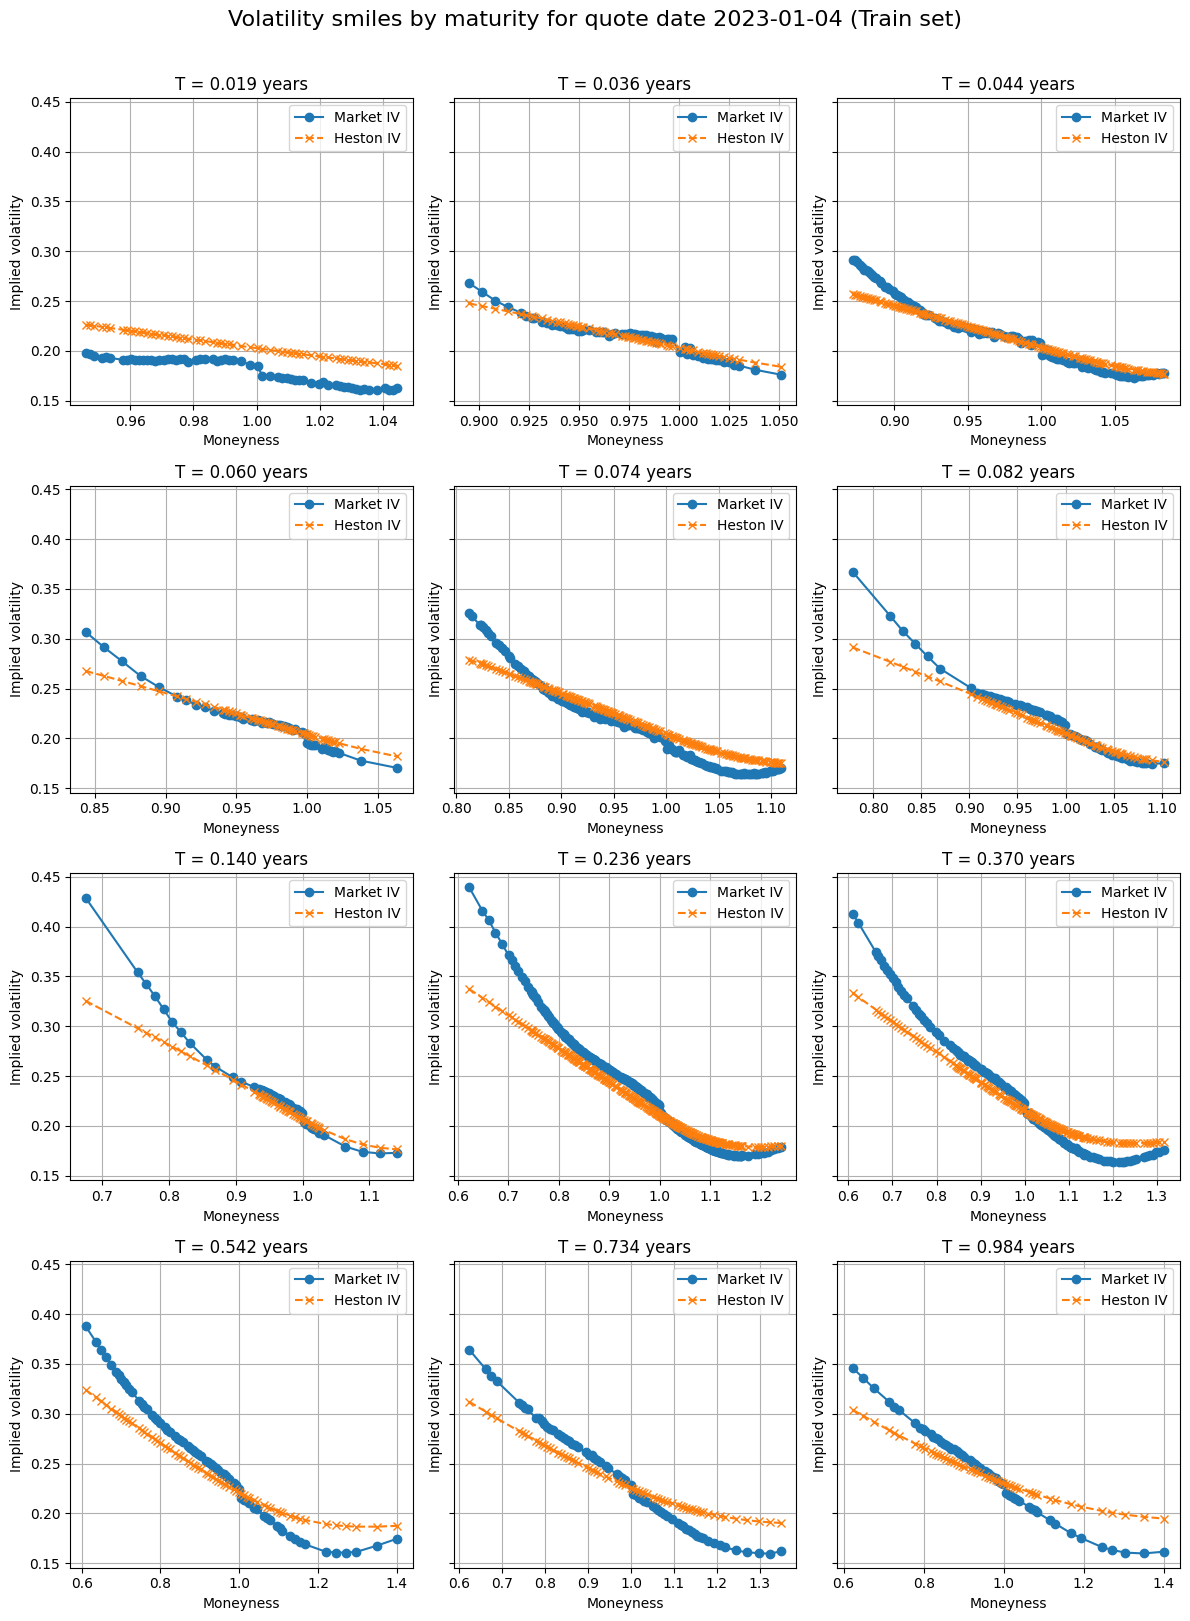

In [16]:
# # ============================================================
# # 2D volatility smiles by maturity (moneyness axis)
# # ============================================================

smile_df = train_result.copy()
smile_df["tau_bucket"] = smile_df["tau"].round(3)
available_taus = np.sort(smile_df["tau_bucket"].unique())
n_smiles = min(12, len(available_taus))
selected_taus = available_taus[np.linspace(0, len(available_taus) - 1, n_smiles).astype(int)]

n_smiles = len(selected_taus)
n_cols = 3
n_rows = int(np.ceil(n_smiles / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), sharey=True)
fig.suptitle(f"Volatility smiles by maturity for quote date {QUOTE_DATE} (Train set)", fontsize=16, y=1.01)
axes = np.array(axes).reshape(-1)

for ax, tau_i in zip(axes, selected_taus):
    sub = smile_df[smile_df["tau_bucket"] == tau_i].sort_values("moneyness")
    if len(sub) < 3:
        ax.set_visible(False)
        continue
    ax.plot(sub["moneyness"], sub["market_iv_from_mid"], marker="o", linestyle="-", label="Market IV")
    ax.plot(sub["moneyness"], sub["heston_iv"], marker="x", linestyle="--", label="Heston IV")
    ax.set_title(f"T = {tau_i:.3f} years")
    ax.set_xlabel("Moneyness")
    ax.set_ylabel("Implied volatility")
    ax.grid(True)
    ax.legend()

for j in range(len(selected_taus), len(axes)):
    axes[j].set_visible(False) 

plt.tight_layout()
plt.show()

## Holdout evaluation

In [17]:
# ============================================================
# Holdout (test) data evaluation
# ============================================================
test_eval = test.copy()
test_eval = test_eval[test_eval["mid"] > 1] # filter out very low-priced options to avoid numerical issues in evaluation
test_eval["moneyness"] = test_eval["strike"] / test_eval["forward"]

K_test = test_eval["strike"].to_numpy(float)
tau_test = test_eval["tau"].to_numpy(float)
r_test = test_eval["rate"].to_numpy(float)
F_test = test_eval["forward"].to_numpy(float)
type_test = test_eval["type"].to_numpy(str)

test_eval["heston_price"] = heston_price_by_type(
    F=F_test, K=K_test, option_type=type_test,
    v0=v0, kappa=kappa, theta=theta, sigma=sigma, rho=rho, lambd=lambd,
    tau=tau_test, r=r_test,
)

test_eval["market_iv_from_mid"] = test_eval['iv']

test_eval["heston_iv"] = [
    implied_vol_bs(price, fwd, strike, t, rate, opt_type)
    for price, fwd, strike, t, rate, opt_type in zip(
        test_eval["heston_price"], test_eval["forward"], test_eval["strike"],
        test_eval["tau"], test_eval["rate"], test_eval["type"])
]

test_eval["price_error"] = test_eval["heston_price"] - test_eval["mid"]
test_eval["rel_price_error"] = test_eval["price_error"] / np.maximum(test_eval["mid"], 1e-8)
test_eval["iv_error"] = test_eval["heston_iv"] - test_eval["market_iv_from_mid"]

vtp = np.isfinite(test_eval["price_error"])
vti = np.isfinite(test_eval["iv_error"])

price_rmse = np.sqrt(np.mean(test_eval.loc[vtp, "price_error"] ** 2))
price_mae = np.mean(np.abs(test_eval.loc[vtp, "price_error"]))
price_mape = np.mean(np.abs(test_eval.loc[vtp, "rel_price_error"]))

iv_rmse = np.sqrt(np.mean(test_eval.loc[vti, "iv_error"] ** 2))
iv_mae = np.mean(np.abs(test_eval.loc[vti, "iv_error"]))


print("Holdout diagnostics")
print("-------------------")
print(f"Holdout options: {len(test_eval):,}")
print(f"Price RMSE: {price_rmse:.6f}")
print(f"Price MAE:  {price_mae:.6f}")
print(f"Price MAPE: {price_mape:.4%}")
print("Holdout implied-volatility diagnostics")
print("----------------------------------------")
print(f"IV RMSE: {iv_rmse:.6f}")
print(f"IV MAE:  {iv_mae:.6f}")

Holdout diagnostics
-------------------
Holdout options: 996
Price RMSE: 9.040566
Price MAE:  4.785839
Price MAPE: 12.4705%
Holdout implied-volatility diagnostics
----------------------------------------
IV RMSE: 0.018304
IV MAE:  0.012903


In [18]:
# ============================================================
# 3D IV surface: market IV and Heston IV
# ============================================================

surface_df = test_eval.copy()

x = surface_df["tau"].to_numpy(float)
y = surface_df["strike"].to_numpy(float)
z = surface_df["market_iv_from_mid"].to_numpy(float)
z_heston = surface_df["heston_iv"].to_numpy(float)

# Grid
tau_grid = np.linspace(x.min(), x.max(), 60)
strike_grid = np.linspace(y.min(), y.max(), 80)
tau_mesh, strike_mesh = np.meshgrid(tau_grid, strike_grid)

market_IV_grid = griddata(points=(x, y), values=z, xi=(tau_mesh, strike_mesh), method="linear")
heston_IV_grid = griddata(points=(x, y), values=z_heston, xi=(tau_mesh, strike_mesh), method="linear")

fig = go.Figure()
# fig.add_trace(go.Surface(
#     x=tau_mesh, y=strike_mesh, z=market_IV_grid,
#     colorscale="Viridis", opacity=0.8))
fig.add_trace(go.Scatter3d(
    x=surface_df["tau"], y=surface_df["strike"], z=surface_df["market_iv_from_mid"],
    mode="markers", name="Market IV", marker=dict(size=3, opacity=0.7)))
fig.add_trace(go.Scatter3d(
    x=surface_df["tau"], y=surface_df["strike"], z=surface_df["heston_iv"],
    mode="markers", name="Heston IV", marker=dict(size=3, opacity=0.7)))
# fig.add_trace(go.Surface(
#     x=tau_mesh, y=strike_mesh, z=heston_IV_grid,
#     colorscale="Cividis", opacity=0.8))
fig.update_layout(
    title="Market IV vs Heston IV Surface (Test set)",
    scene=dict(xaxis_title="Time to maturity", yaxis_title="Strike", zaxis_title="Implied volatility"),
    width=900, height=700)
fig.show()

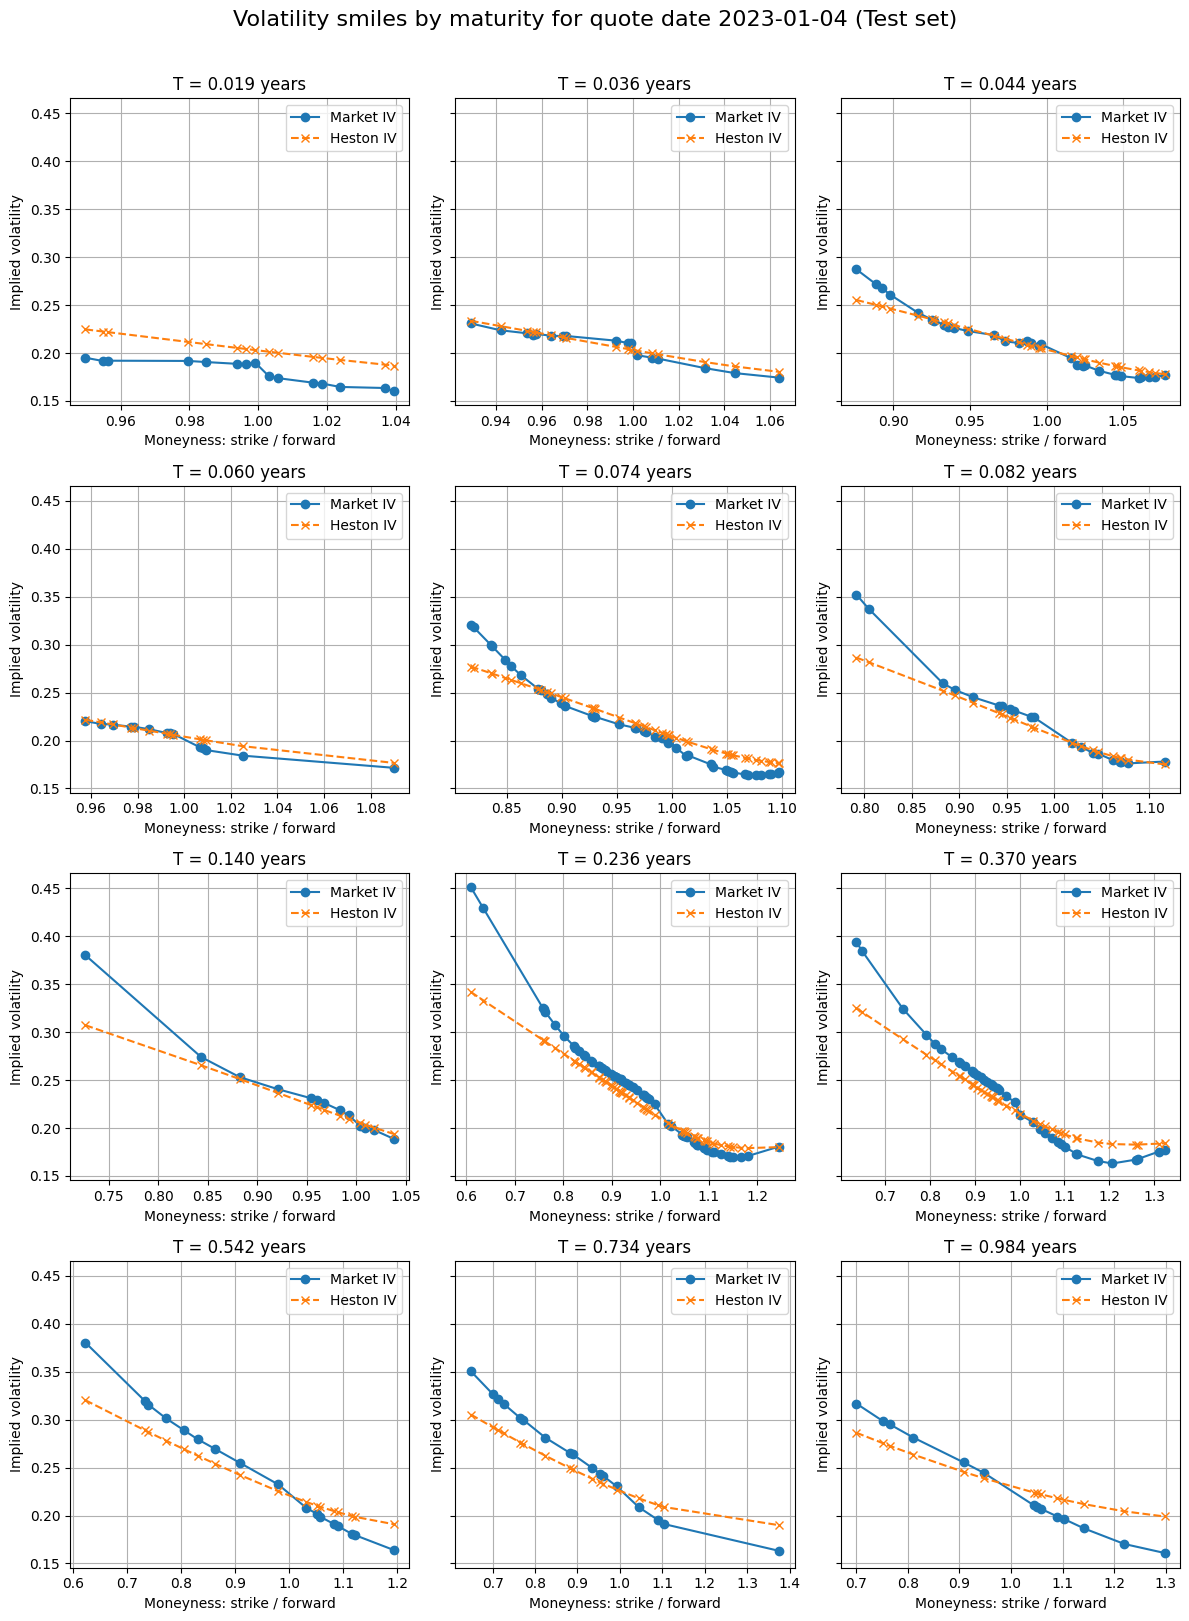

In [19]:
# # ============================================================
# # 2D volatility smiles by maturity (moneyness axis)
# # ============================================================

smile_df = test_eval.copy()

smile_df["tau_bucket"] = smile_df["tau"].round(3)
available_taus = np.sort(smile_df["tau_bucket"].unique())
n_smiles = min(12, len(available_taus))
selected_taus = available_taus[np.linspace(0, len(available_taus) - 1, n_smiles).astype(int)]

n_smiles = len(selected_taus)
n_cols = 3
n_rows = int(np.ceil(n_smiles / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), sharey=True)
fig.suptitle(f"Volatility smiles by maturity for quote date {QUOTE_DATE} (Test set)", fontsize=16, y=1.01)
axes = np.array(axes).reshape(-1)

for ax, tau_i in zip(axes, selected_taus):
    sub = smile_df[smile_df["tau_bucket"] == tau_i].sort_values("moneyness")
    if len(sub) < 3:
        ax.set_visible(False)
        continue
    ax.plot(sub["moneyness"], sub["market_iv_from_mid"], marker="o", linestyle="-", label="Market IV")
    ax.plot(sub["moneyness"], sub["heston_iv"], marker="x", linestyle="--", label="Heston IV")
    ax.set_title(f"T = {tau_i:.3f} years")
    ax.set_xlabel("Moneyness: strike / forward")
    ax.set_ylabel("Implied volatility")
    ax.grid(True)
    ax.legend()

for j in range(len(selected_taus), len(axes)):
    axes[j].set_visible(False)


plt.tight_layout()
plt.show()

## Arbitrage check

#### Single option no-arbitrage bounds

In [20]:
def option_bounds_forward(F, K, T, r, option_type):
    if option_type == "call":
        lower = np.exp(-r * T) * max(F - K, 0.0)
        upper = np.exp(-r * T) * F
    elif option_type == "put":
        lower = np.exp(-r * T) * max(K - F, 0.0)
        upper = np.exp(-r * T) * K
    else:
        lower, upper = np.nan, np.nan

    return lower, upper

bounds = np.array([
    option_bounds_forward(f, k, t, rr, typ)
    for f, k, t, rr, typ in zip(
        train_calib["forward"],
        train_calib["strike"],
        train_calib["tau"],
        train_calib["rate"],
        train_calib["type"]
    )
])

train_calib["lower_bound"] = bounds[:, 0]
train_calib["upper_bound"] = bounds[:, 1]

tol = 1e-8

train_calib["market_bound_violation"] = (
    (train_calib["mid"] < train_calib["lower_bound"] - tol) |
    (train_calib["mid"] > train_calib["upper_bound"] + tol)
)

print(train_calib["market_bound_violation"].sum())
train_calib.loc[
    train_calib["market_bound_violation"],
    ["type", "strike", "forward", "tau", "rate", "mid", "lower_bound", "upper_bound"]
].head()

0


,type,strike,forward,tau,rate,mid,lower_bound,upper_bound


In [21]:
train_result["lower_bound"] = [
    option_bounds_forward(f, k, t, rr, typ)[0]
    for f, k, t, rr, typ in zip(
        train_result["forward"],
        train_result["strike"],
        train_result["tau"],
        train_result["rate"],
        train_result["type"]
    )
]

train_result["upper_bound"] = [
    option_bounds_forward(f, k, t, rr, typ)[1]
    for f, k, t, rr, typ in zip(
        train_result["forward"],
        train_result["strike"],
        train_result["tau"],
        train_result["rate"],
        train_result["type"]
    )
]

train_result["heston_bound_violation"] = (
    (train_result["heston_price"] < train_result["lower_bound"] - tol) |
    (train_result["heston_price"] > train_result["upper_bound"] + tol)
)

print(train_result["heston_bound_violation"].sum())
train_result[train_result["heston_bound_violation"] == True]
train_result

0


,type,strike,tau,rate,forward,moneyness,mid,iv,heston_price,market_iv_from_mid,heston_iv,price_error,rel_price_error,iv_error,lower_bound,upper_bound,heston_bound_violation
0,put,3645.0,0.019178,0.044821,3853.39,0.945920,1.075,0.19810,1.789173,0.19810,0.226334,0.714173,0.664347,0.028234,0.0,3641.868154,False
1,put,3650.0,0.019178,0.044821,3853.39,0.947218,1.175,0.19648,1.969361,0.19648,0.225771,0.794361,0.676051,0.029291,0.0,3646.863858,False
2,put,3655.0,0.019178,0.044821,3853.39,0.948515,1.275,0.19520,2.165664,0.19520,0.225207,0.890664,0.698560,0.030007,0.0,3651.859562,False
3,put,3665.0,0.019178,0.044821,3853.39,0.951111,1.525,0.19262,2.611560,0.19262,0.224076,1.086560,0.712499,0.031456,0.0,3661.850969,False
4,put,3670.0,0.019178,0.044821,3853.39,0.952408,1.725,0.19330,2.863798,0.19330,0.223509,1.138798,0.660173,0.030209,0.0,3666.846673,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3934,call,4800.0,0.983562,0.044863,3853.39,1.245656,47.350,0.16600,57.101128,0.16600,0.202365,9.751128,0.205937,0.036365,0.0,3687.054080,False
3935,call,4900.0,0.983562,0.044863,3853.39,1.271608,35.000,0.16309,45.490147,0.16309,0.200566,10.490147,0.299718,0.037476,0.0,3687.054080,False
3936,call,5025.0,0.983562,0.044863,3853.39,1.304047,23.750,0.16051,33.974279,0.16051,0.198622,10.224279,0.430496,0.038112,0.0,3687.054080,False
3937,call,5200.0,0.983562,0.044863,3853.39,1.349461,14.350,0.15965,22.315896,0.15965,0.196440,7.965896,0.555115,0.036790,0.0,3687.054080,False


#### Vertical spread monotonicity across strikes

For fixed expiry, call prices should decrease as strike increases and Put prices should increase as strike increases:

In [22]:
def check_vertical_monotonicity(frame, price_col="mid"):
    out = []

    for (exp, typ), sub in frame.groupby(["tau", "type"]):
        sub = sub.sort_values("strike").copy()

        if len(sub) < 2:
            continue

        dp = sub[price_col].diff()

        if typ == "call":
            violation = dp > 1e-8
        elif typ == "put":
            violation = dp < -1e-8
        else:
            continue

        tmp = sub.loc[violation, ["tau", "type", "strike", price_col]].copy()
        tmp["price_diff"] = dp.loc[violation]
        out.append(tmp)

    if len(out) == 0:
        return pd.DataFrame()

    return pd.concat(out, ignore_index=True)

market_vertical_viol = check_vertical_monotonicity(train_result, price_col="mid")
print(len(market_vertical_viol))
market_vertical_viol.head()

4


,tau,type,strike,mid,price_diff
0,0.090411,put,3795.0,67.25,-0.05
1,0.120548,put,3680.0,48.90,-0.05
2,0.197151,put,3585.0,53.80,-0.05
3,0.197151,put,3685.0,77.50,-0.05


In [23]:
heston_vertical_viol = check_vertical_monotonicity(train_result, price_col="heston_price")
print(len(heston_vertical_viol))
heston_vertical_viol.head()

0


,tau,type,strike,heston_price,price_diff


#### Butterfly convexity across strikes

For fixed maturity, option price should be convex in strike.

In [24]:
def check_convexity_by_strike(frame, price_col="mid"):
    out = []

    for (exp, typ), sub in frame.groupby(["tau", "type"]):
        sub = sub.sort_values("strike").copy()

        K = sub["strike"].to_numpy(float)
        V = sub[price_col].to_numpy(float)

        if len(sub) < 3:
            continue

        slope_left = (V[1:-1] - V[:-2]) / (K[1:-1] - K[:-2])
        slope_right = (V[2:] - V[1:-1]) / (K[2:] - K[1:-1])

        violation = slope_right < slope_left - 1e-8

        tmp = sub.iloc[1:-1].loc[violation, ["tau", "type", "strike", price_col]].copy()
        tmp["slope_left"] = slope_left[violation]
        tmp["slope_right"] = slope_right[violation]

        out.append(tmp)

    if len(out) == 0:
        return pd.DataFrame()

    return pd.concat(out, ignore_index=True)

market_bfly_viol = check_convexity_by_strike(train_calib, price_col="mid")
print("Market butterfly violations:", len(market_bfly_viol))

heston_bfly_viol = check_convexity_by_strike(train_result, price_col="heston_price")
print("Heston butterfly violations:", len(heston_bfly_viol))

Market butterfly violations: 1113
Heston butterfly violations: 0


#### Calendar spread arbitrage

In [25]:
def check_calendar_total_variance(frame, iv_col="market_iv_from_mid", k_col="log_moneyness", tau_col="tau", n_grid=80, tol=1e-8):
    """
    Checks calendar-spread arbitrage using total implied variance.

    For fixed log-forward moneyness k = log(K/F), total variance
        w(k,T) = IV(k,T)^2 * T
    should be nondecreasing in maturity T.

    Returns a DataFrame of calendar violations.
    """

    df = frame.copy()

    if k_col not in df.columns:
        df[k_col] = np.log(df["strike"] / df["forward"])

    df = df[np.isfinite(df[k_col]) & np.isfinite(df[tau_col]) & np.isfinite(df[iv_col]) & (df[tau_col] > 0) & (df[iv_col] > 0)].copy()

    if df.empty:
        return pd.DataFrame()

    # Use only maturities with enough points
    maturities = np.sort(df[tau_col].unique())

    rows = []

    for t1, t2 in zip(maturities[:-1], maturities[1:]):
        sub1 = df[df[tau_col] == t1].sort_values(k_col)
        sub2 = df[df[tau_col] == t2].sort_values(k_col)

        if len(sub1) < 3 or len(sub2) < 3:
            continue

        k_min = max(sub1[k_col].min(), sub2[k_col].min())
        k_max = min(sub1[k_col].max(), sub2[k_col].max())

        if k_min >= k_max:
            continue

        k_grid = np.linspace(k_min, k_max, n_grid)

        iv1 = np.interp(k_grid, sub1[k_col], sub1[iv_col])
        iv2 = np.interp(k_grid, sub2[k_col], sub2[iv_col])

        w1 = iv1 ** 2 * t1
        w2 = iv2 ** 2 * t2

        violation = w2 < w1 - tol

        for k, a, b, v1, v2 in zip(
            k_grid[violation],
            w1[violation],
            w2[violation],
            iv1[violation],
            iv2[violation],
        ):
            rows.append({
                "tau_short": t1,
                "tau_long": t2,
                "log_moneyness": k,
                "moneyness": np.exp(k),
                "iv_short": v1,
                "iv_long": v2,
                "total_var_short": a,
                "total_var_long": b,
                "calendar_violation": a - b,
            })

    return pd.DataFrame(rows)

In [26]:
market_calendar_viol = check_calendar_total_variance(
    train_result,
    iv_col="market_iv_from_mid"
)

print("Market calendar violations:", len(market_calendar_viol))
market_calendar_viol.sort_values("calendar_violation", ascending=False).head(20)

Market calendar violations: 6


,tau_short,tau_long,log_moneyness,moneyness,iv_short,iv_long,total_var_short,total_var_long,calendar_violation
1,0.041096,0.043836,0.000311,1.000311,0.206423,0.196799,0.001751,0.001698,0.000053
4,0.052055,0.054795,0.000261,1.000261,0.200096,0.192956,0.002084,0.002040,0.000044
3,0.041096,0.043836,0.010597,1.010654,0.200706,0.191885,0.001655,0.001614,0.000041
0,0.041096,0.043836,-0.014089,0.986010,0.216173,0.208284,0.001920,0.001902,0.000019
5,0.076712,0.079452,0.086131,1.089949,0.174869,0.171360,0.002346,0.002333,0.000013
2,0.041096,0.043836,0.008540,1.008577,0.200507,0.193857,0.001652,0.001647,0.000005


In [27]:
heston_calendar_viol = check_calendar_total_variance(
    train_result,
    iv_col="heston_iv"
)

print("Heston calendar violations:", len(heston_calendar_viol))
# heston_calendar_viol.sort_values("calendar_violation", ascending=False).head(20)

Heston calendar violations: 0
